In [ ]:
# Time series analysis with market share overlay
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Changes with Market Share Trends', fontsize=18, fontweight='bold')

# Prepare market share change data
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    
    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)
        
        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)
        
        # Stacked area chart for sentiment
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.6, 
                                  color=['#ff6b6b', '#808080', '#45b7d1'])
        
        # Add market share change rate line (secondary y-axis)
        ax2 = ax.twinx()
        
        # Plot market share change for the specific model
        if model == 'chatgpt' and 'ChatGPT_Change' in market_share_change.columns:
            ax2.plot(market_share_change['Month'], market_share_change['ChatGPT_Change'], 
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share Change (%)')
        elif model == 'claude' and 'Claude_Change' in market_share_change.columns:
            ax2.plot(market_share_change['Month'], market_share_change['Claude_Change'], 
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share Change (%)')
        elif model == 'gemini' and 'Gemini_Change' in market_share_change.columns:
            ax2.plot(market_share_change['Month'], market_share_change['Gemini_Change'], 
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share Change (%)')
        
        ax.set_title(f'{model.upper()} Model - Sentiment & Market Share Changes\n({len(model_mentioned)} mentions)', fontsize=14, fontweight='bold')
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax2.set_ylabel('Market Share Change Rate (%)', fontsize=10)
        ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.9))
        
    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)
    
    ax.set_ylabel('Sentiment Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Additional Data Analysis: Market Share and Benchmark Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import ast

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load CSV file
df = pd.read_csv('model/result.csv')
print(f"Data shape: {df.shape}")
print(f"Column names: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Data shape: (20176, 11)
Column names: ['Post_ID', 'Type', 'Data', 'Timestamp', 'category', 'label(chatgpt,claude,grok,gemini)', 'comment', 'multi_head pred_vector', 'multi_head prob_vector', 'multi_label pred_vector', 'multi_label prob_vector']

First 5 rows:


,Post_ID,Type,Data,Timestamp,category,"label(chatgpt,claude,grok,gemini)",comment,multi_head pred_vector,multi_head prob_vector,multi_label pred_vector,multi_label prob_vector
0,1ix91px,2,both chatgpt and claude adjust the precision o...,2025-02-25 03:44:35,"('chatgpt', 'claude')","[-1,-1,0,0]",NaN,"[-1, -1, 0, 0]","[0.5860000252723694, 0.0010000000474974513, 0....","[-1, -1, 0, 0]","[0.9919999837875366, 0.0, 0.00800000037997961,..."
1,1jlzgub,2,the trend of people getting their information ...,2025-03-29 02:58:22,"('chatgpt', 'gemini')","[-1,0,0,0]",NaN,"[-1, 0, 0, -1]","[0.8080000281333923, 0.041999999433755875, 0.1...","[-1, 0, 0, 0]","[0.9919999837875366, 0.0, 0.00800000037997961,..."
2,1gr9k1g,2,"rather no than yes, but this wasn't just a pro...",2024-11-15 09:35:25,"('chatgpt', 'gemini')","[-1,0,0,0]",NaN,"[-1, 0, 0, 0]","[0.9160000085830688, 0.013000000268220901, 0.0...","[-1, 0, 0, 0]","[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, ..."
3,1ixisq1,2,i was sold with o1 pro but $200/month seemed r...,2025-02-26 03:11:32,"('chatgpt', 'claude')","[-1,1,0,0]",NaN,"[1, -1, 0, 0]","[0.2800000011920929, 0.003000000026077032, 0.7...","[1, -1, 0, 0]","[0.023000000044703484, 0.0, 0.9769999980926514..."
4,1jftq3x,2,claude had projects before chatgpt did.,2025-03-21 11:04:53,"('chatgpt', 'claude')","[-1,1,0,0]",NaN,"[-1, 1, 0, 0]","[0.9430000185966492, 0.0010000000474974513, 0....","[-1, 1, 0, 0]","[0.996999979019165, 0.0, 0.003000000026077032,..."


In [3]:
# Analyze multi_head pred_vector column
# Convert string-stored lists to actual lists
df['multi_head_pred_parsed'] = df['multi_head pred_vector'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else None)

# Extract prediction values for each model (chatgpt, claude, grok, gemini order)
model_names = ['chatgpt', 'claude', 'grok', 'gemini']
for i, model in enumerate(model_names):
    df[f'{model}_pred'] = df['multi_head_pred_parsed'].apply(lambda x: x[i] if x is not None else None)

print("multi_head pred_vector parsing completed")
print(f"Prediction value distribution by model:")
for model in model_names:
    print(f"\n{model} prediction distribution:")
    print(df[f'{model}_pred'].value_counts().sort_index())

multi_head pred_vector parsing completed
Prediction value distribution by model:

chatgpt prediction distribution:
chatgpt_pred
-1     2663
 0    13030
 1     4483
Name: count, dtype: int64

claude prediction distribution:
claude_pred
-1     1244
 0    16721
 1     2211
Name: count, dtype: int64

grok prediction distribution:
grok_pred
-1     2026
 0    16376
 1     1774
Name: count, dtype: int64

gemini prediction distribution:
gemini_pred
-1     1427
 0    17044
 1     1705
Name: count, dtype: int64


CHATGPT: 9036 records where model is mentioned
CLAUDE: 4507 records where model is mentioned
GROK: 4245 records where model is mentioned
GEMINI: 4300 records where model is mentioned


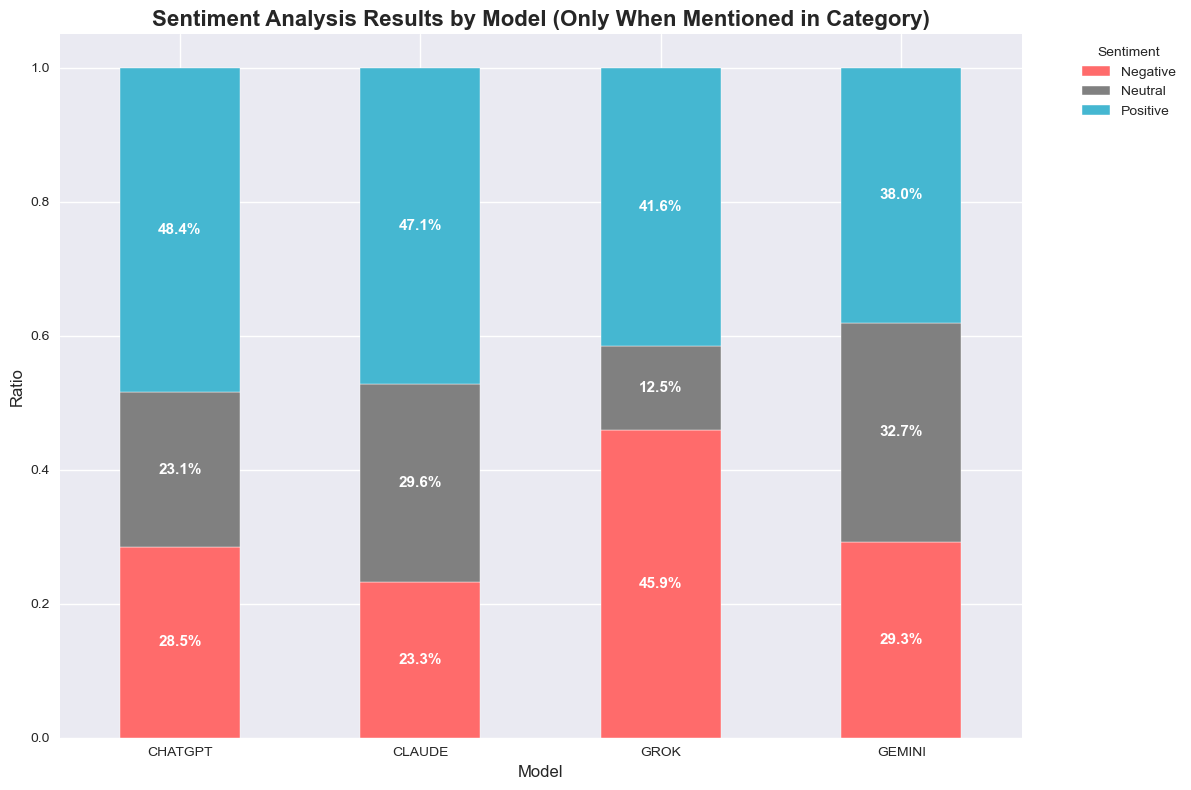

In [4]:
# Define sentiment labels (-1: Negative, 0: Neutral, 1: Positive)
sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

# Parse category column to extract mentioned models
df['category_parsed'] = df['category'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Calculate sentiment ratios for each model (only when the model is mentioned in category)
sentiment_ratios = {}
for model in model_names:
    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    
    if len(model_mentioned) > 0:
        ratios = model_mentioned[f'{model}_pred'].value_counts(normalize=True).sort_index()
        sentiment_ratios[model] = ratios
        print(f"{model.upper()}: {len(model_mentioned)} records where model is mentioned")
    else:
        print(f"{model.upper()}: No records found")

# Visualization 1: Stacked bar chart by model (only when mentioned in category)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Organize data for stacked bar chart
comparison_data = pd.DataFrame(sentiment_ratios).fillna(0).T  # Transpose to have models as rows
comparison_data.columns = [sentiment_labels[idx] for idx in comparison_data.columns]

# Create stacked bar chart
colors = ['#ff6b6b', '#808080', '#45b7d1']  # Negative, Neutral (gray), Positive
comparison_data.plot(kind='bar', stacked=True, ax=ax, color=colors, figsize=(12, 8))

ax.set_title('Sentiment Analysis Results by Model (Only When Mentioned in Category)', fontsize=16, fontweight='bold')
ax.set_ylabel('Ratio', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels([model.upper() for model in sentiment_ratios.keys()], rotation=0)

# Add percentage labels on bars
for i, model in enumerate(sentiment_ratios.keys()):
    ratios = sentiment_ratios[model]
    cumulative = 0
    for j, sentiment_val in enumerate(sorted(ratios.index)):
        if sentiment_val in ratios:
            value = ratios[sentiment_val]
            ax.text(i, cumulative + value/2, f'{value:.1%}', 
                   ha='center', va='center', fontsize=11, fontweight='bold', color='white')
            cumulative += value

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

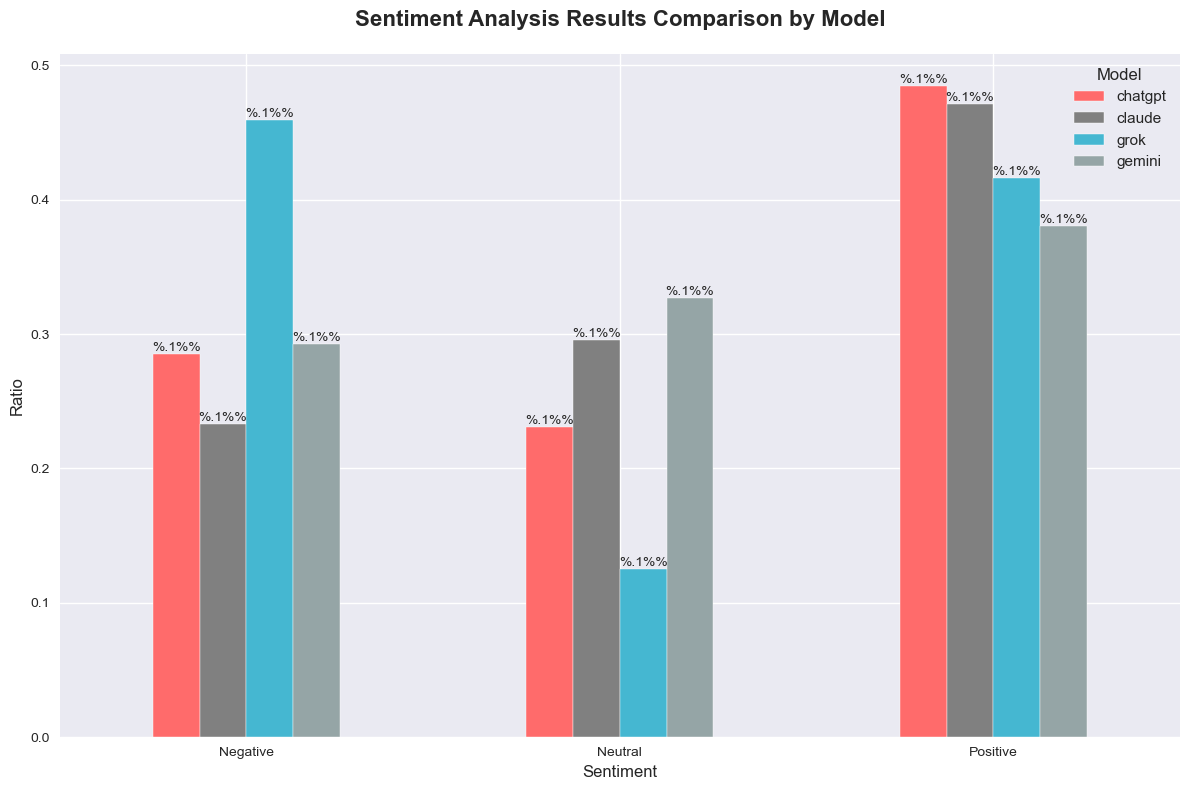

In [5]:
# Visualization 2: Model comparison bar chart
plt.figure(figsize=(14, 8))

# Organize data
comparison_data = pd.DataFrame(sentiment_ratios).fillna(0)
comparison_data.index = [sentiment_labels[idx] for idx in comparison_data.index]

# Create bar chart
ax = comparison_data.plot(kind='bar', figsize=(12, 8), color=['#ff6b6b', '#808080', '#45b7d1', '#95a5a6'])
plt.title('Sentiment Analysis Results Comparison by Model', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Ratio', fontsize=12)
plt.xlabel('Sentiment', fontsize=12)
plt.legend(title='Model', title_fontsize=12, fontsize=11, loc='upper right')
plt.xticks(rotation=0)

# Display values
for container in ax.containers:
    ax.bar_label(container, fmt='%.1%%', label_type='edge', fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
# Convert Timestamp column to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date
df['Month'] = df['Timestamp'].dt.to_period('M')

print("Time data conversion completed")
print(f"Data period: {df['Timestamp'].min()} ~ {df['Timestamp'].max()}")
print(f"Total period: {(df['Timestamp'].max() - df['Timestamp'].min()).days} days")

Time data conversion completed
Data period: 2024-11-03 03:00:48 ~ 2025-06-20 18:04:19
Total period: 229 days


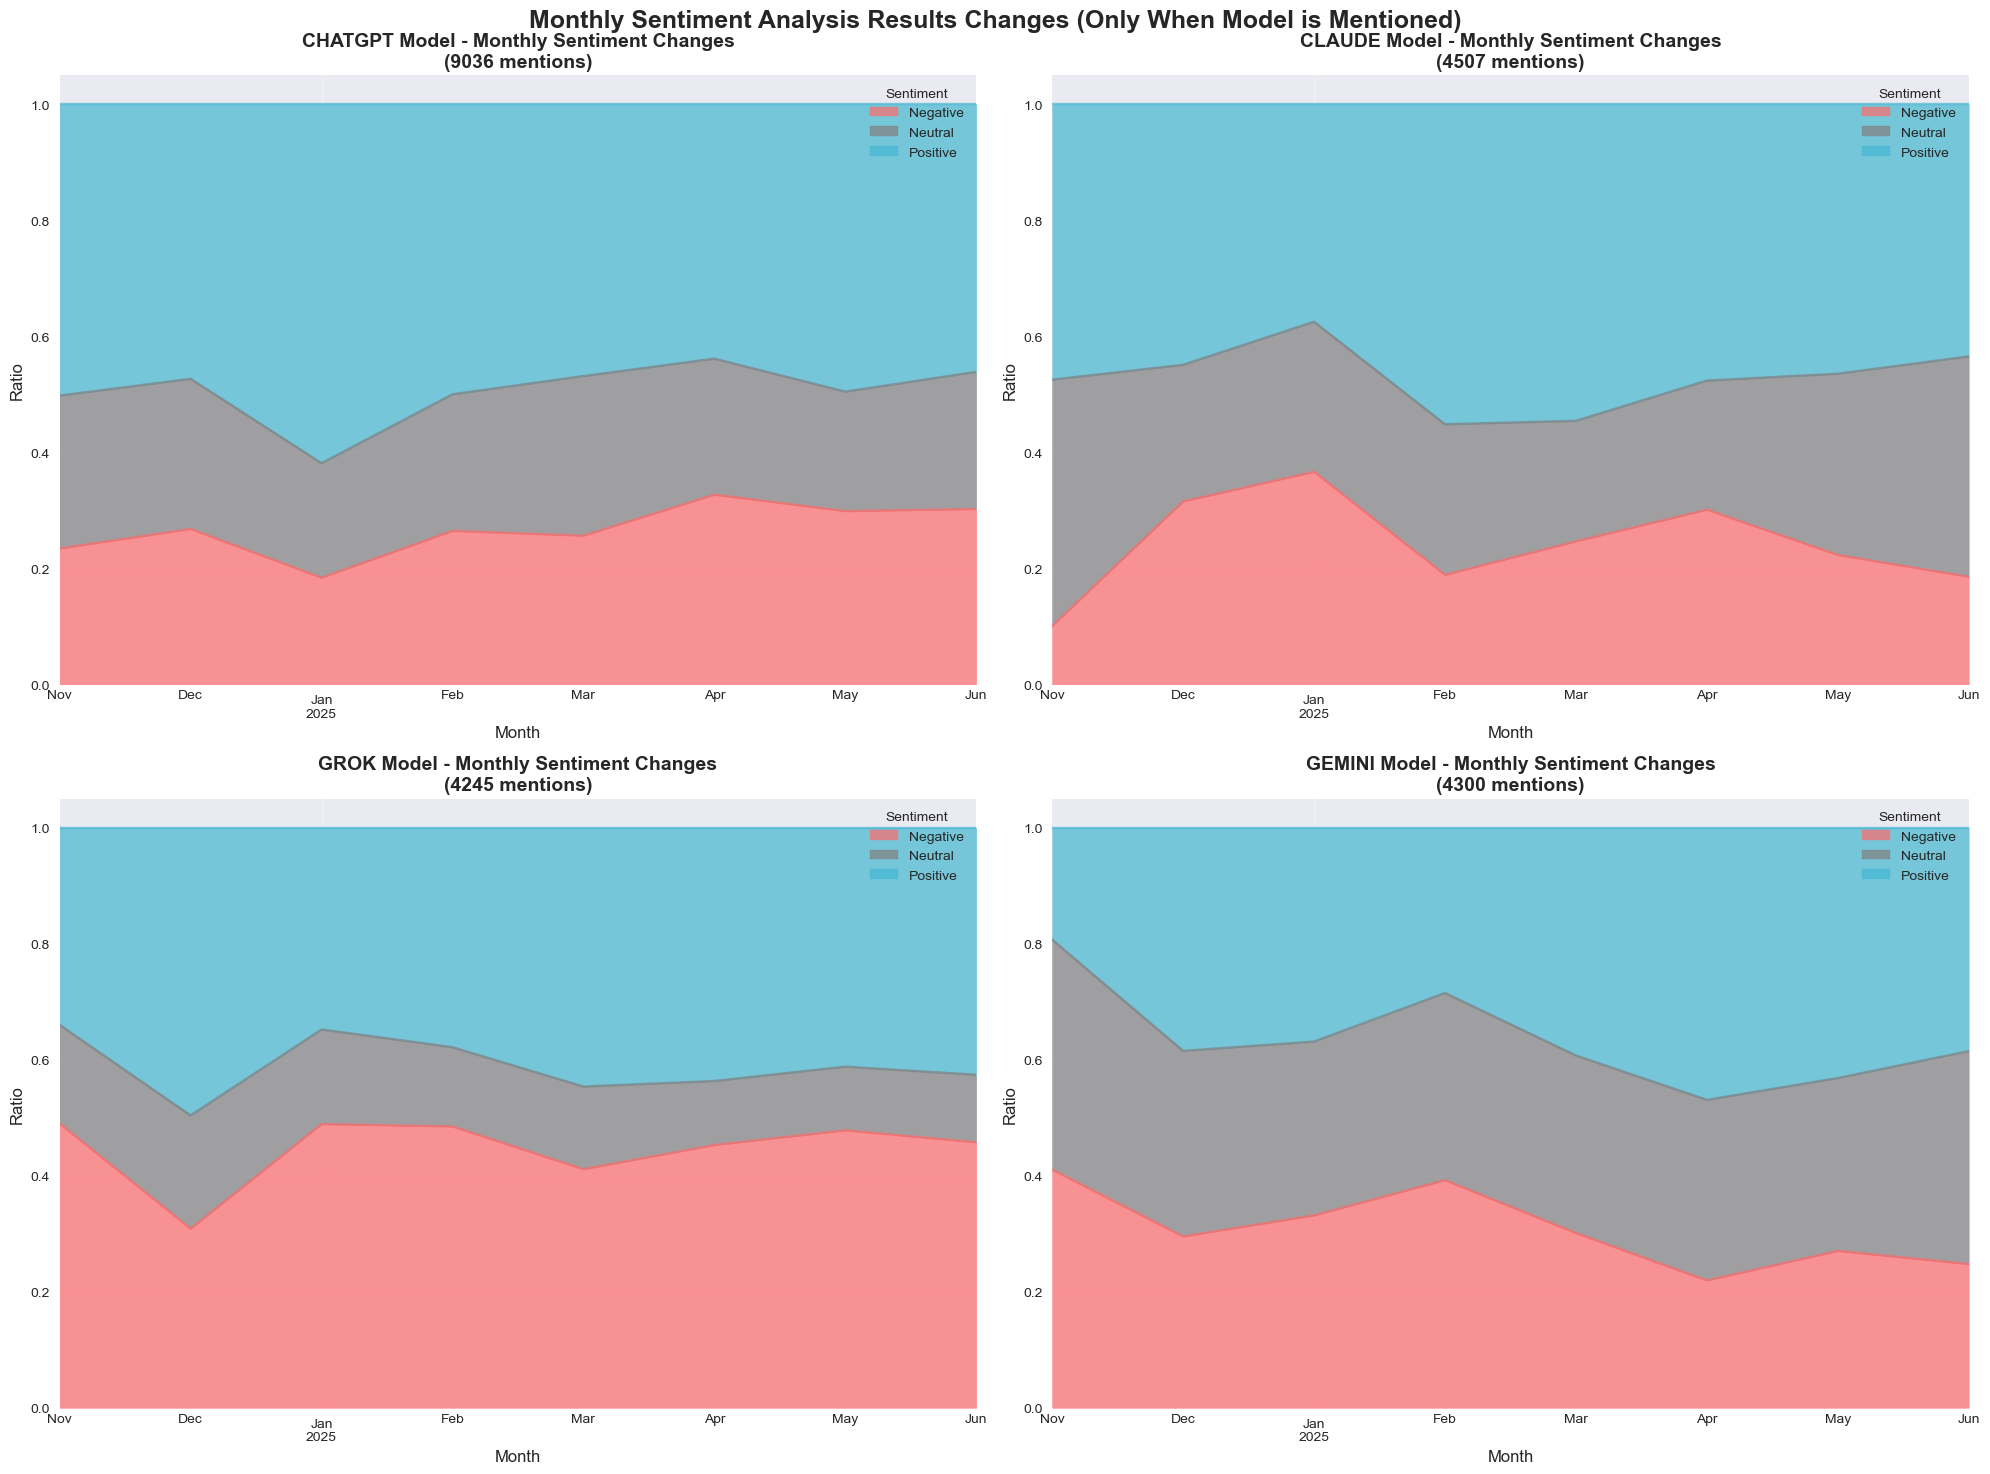

In [7]:
# Time series analysis: Monthly sentiment distribution changes (only when model is mentioned)
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Analysis Results Changes (Only When Model is Mentioned)', fontsize=18, fontweight='bold')

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    
    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)
        
        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)
        
        # Stacked area chart
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.7, 
                                  color=['#ff6b6b', '#808080', '#45b7d1'])
        
        ax.set_title(f'{model.upper()} Model - Monthly Sentiment Changes\n({len(model_mentioned)} mentions)', fontsize=14, fontweight='bold')
    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)
    
    ax.set_ylabel('Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

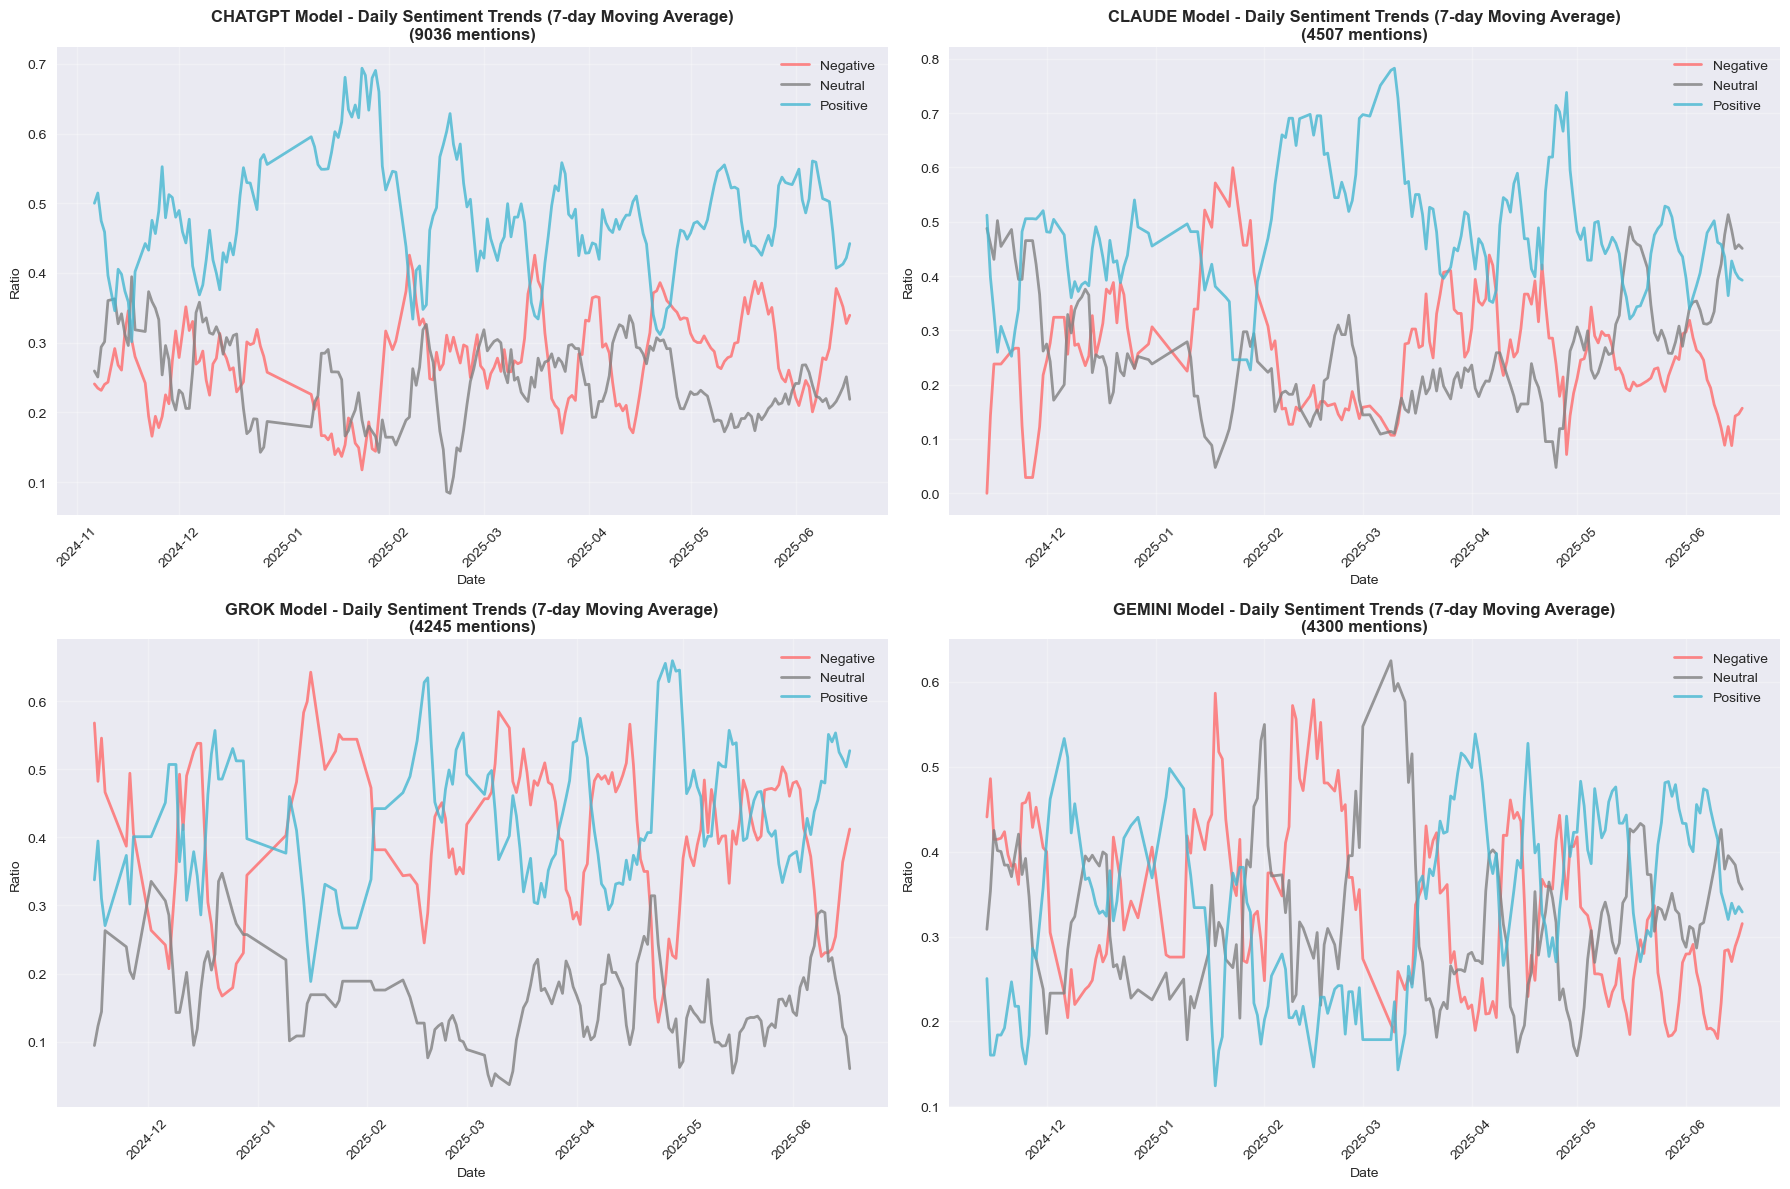

In [8]:
# Time series analysis: Daily sentiment trends (Line chart)
plt.figure(figsize=(18, 12))

# Daily data aggregation (with 7-day moving average)
for i, model in enumerate(model_names):
    plt.subplot(2, 2, i+1)
    
    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    
    if len(model_mentioned) > 0:
        # Calculate daily sentiment ratios
        daily_sentiment = model_mentioned.groupby(['Date', f'{model}_pred']).size().unstack(fill_value=0)
        daily_sentiment_pct = daily_sentiment.div(daily_sentiment.sum(axis=1), axis=0)
        
        # Apply 7-day moving average
        daily_sentiment_smooth = daily_sentiment_pct.rolling(window=7, center=True).mean()
        
        # Line plot by sentiment
        for sentiment_val, color in zip([-1, 0, 1], ['#ff6b6b', '#808080', '#45b7d1']):
            if sentiment_val in daily_sentiment_smooth.columns:
                plt.plot(daily_sentiment_smooth.index, daily_sentiment_smooth[sentiment_val], 
                        color=color, label=sentiment_labels[sentiment_val], linewidth=2, alpha=0.8)
        
        plt.title(f'{model.upper()} Model - Daily Sentiment Trends (7-day Moving Average)\n({len(model_mentioned)} mentions)', fontsize=12, fontweight='bold')
        plt.ylabel('Ratio', fontsize=10)
        plt.xlabel('Date', fontsize=10)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
    else:
        plt.title(f'{model.upper()} Model - No mentions found', fontsize=12, fontweight='bold')
        plt.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics and insights
print("=== Sentiment Analysis Summary ===")
print("\n1. Overall sentiment distribution by model:")
for model in model_names:
    ratios = df[f'{model}_pred'].value_counts(normalize=True).sort_index()
    print(f"\n{model.upper()}:")
    for sentiment_val, ratio in ratios.items():
        print(f"  {sentiment_labels[sentiment_val]}: {ratio:.1%}")

print("\n2. Model characteristics:")
for model in model_names:
    ratios = df[f'{model}_pred'].value_counts(normalize=True).sort_index()
    max_sentiment = ratios.idxmax()
    print(f"{model.upper()}: {sentiment_labels[max_sentiment]} sentiment is highest ({ratios[max_sentiment]:.1%})")

print(f"\n3. Data period: {df['Timestamp'].min().strftime('%Y-%m-%d')} ~ {df['Timestamp'].max().strftime('%Y-%m-%d')}")
print(f"Total data count: {len(df):,} records")

=== Sentiment Analysis Summary ===

1. Overall sentiment distribution by model:

CHATGPT:
  Negative: 13.2%
  Neutral: 64.6%
  Positive: 22.2%

CLAUDE:
  Negative: 6.2%
  Neutral: 82.9%
  Positive: 11.0%

GROK:
  Negative: 10.0%
  Neutral: 81.2%
  Positive: 8.8%

GEMINI:
  Negative: 7.1%
  Neutral: 84.5%
  Positive: 8.5%

2. Model characteristics:
CHATGPT: Neutral sentiment is highest (64.6%)
CLAUDE: Neutral sentiment is highest (82.9%)
GROK: Neutral sentiment is highest (81.2%)
GEMINI: Neutral sentiment is highest (84.5%)

3. Data period: 2024-11-03 ~ 2025-06-20
Total data count: 20,176 records


In [11]:
# Load additional datasets
# Load benchmark MMLU data
benchmark_df = pd.read_csv('data/raw_data/else/benchmark_mmlu', encoding='utf-8')
print("Benchmark MMLU Data:")
print(benchmark_df.head())
print(f"Shape: {benchmark_df.shape}")

# Load market share data
market_share_df = pd.read_csv('data/raw_data/else/market_share.csv')
print("\nMarket Share Data:")
print(market_share_df.head())
print(f"Shape: {market_share_df.shape}")

Benchmark MMLU Data:
           월 ChatGPT (OpenAI) Claude (Anthropic) Grok (xAI) Gemini (Google)
0  2024년 10월           91.00%             88.30%     87.50%          86.00%
1  2024년 11월           91.00%             88.30%     87.50%          86.00%
2  2024년 12월           91.00%             88.30%     87.50%          87.00%
3   2025년 1월           91.00%             88.30%     87.50%          87.00%
4   2025년 2월           91.00%             88.30%     92.70%          87.00%
Shape: (8, 5)

Market Share Data:
           Month  ChatGPT Market Share (%)  Gemini Market Share (%)  \
0   October 2024                      73.6                     13.5   
1  November 2024                      73.8                     13.5   
2  December 2024                      73.8                     13.4   
3   January 2025                      74.2                     13.5   
4  February 2025                      74.1                     13.5   

   ClaudeAI Market Share (%)  
0                        2.8  


In [12]:
# Clean and process benchmark data
benchmark_df_clean = benchmark_df.copy()
benchmark_df_clean['Month'] = pd.to_datetime(benchmark_df_clean['월'], format='%Y년 %m월')

# Convert percentage strings to numeric values
model_cols_benchmark = ['ChatGPT (OpenAI)', 'Claude (Anthropic)', 'Grok (xAI)', 'Gemini (Google)']
for col in model_cols_benchmark:
    benchmark_df_clean[col] = benchmark_df_clean[col].str.replace('%', '').astype(float)

# Rename columns for consistency
benchmark_df_clean = benchmark_df_clean.rename(columns={
    'ChatGPT (OpenAI)': 'ChatGPT_Benchmark',
    'Claude (Anthropic)': 'Claude_Benchmark',
    'Grok (xAI)': 'Grok_Benchmark',
    'Gemini (Google)': 'Gemini_Benchmark'
})

print("Cleaned Benchmark Data:")
print(benchmark_df_clean.head())

Cleaned Benchmark Data:
           월  ChatGPT_Benchmark  Claude_Benchmark  Grok_Benchmark  \
0  2024년 10월               91.0              88.3            87.5   
1  2024년 11월               91.0              88.3            87.5   
2  2024년 12월               91.0              88.3            87.5   
3   2025년 1월               91.0              88.3            87.5   
4   2025년 2월               91.0              88.3            92.7   

   Gemini_Benchmark      Month  
0              86.0 2024-10-01  
1              86.0 2024-11-01  
2              87.0 2024-12-01  
3              87.0 2025-01-01  
4              87.0 2025-02-01  


In [13]:
# Clean and process market share data
market_share_df_clean = market_share_df.copy()
market_share_df_clean['Month'] = pd.to_datetime(market_share_df_clean['Month'], format='%B %Y')

# Rename columns for consistency
market_share_df_clean = market_share_df_clean.rename(columns={
    'ChatGPT Market Share (%)': 'ChatGPT_MarketShare',
    'Gemini Market Share (%)': 'Gemini_MarketShare',
    'ClaudeAI Market Share (%)': 'Claude_MarketShare'
})

print("Cleaned Market Share Data:")
print(market_share_df_clean.head())

# Note: Grok is not in market share data, so we'll need to handle that

Cleaned Market Share Data:
       Month  ChatGPT_MarketShare  Gemini_MarketShare  Claude_MarketShare
0 2024-10-01                 73.6                13.5                 2.8
1 2024-11-01                 73.8                13.5                 2.9
2 2024-12-01                 73.8                13.4                 3.1
3 2025-01-01                 74.2                13.5                 3.1
4 2025-02-01                 74.1                13.5                 3.2


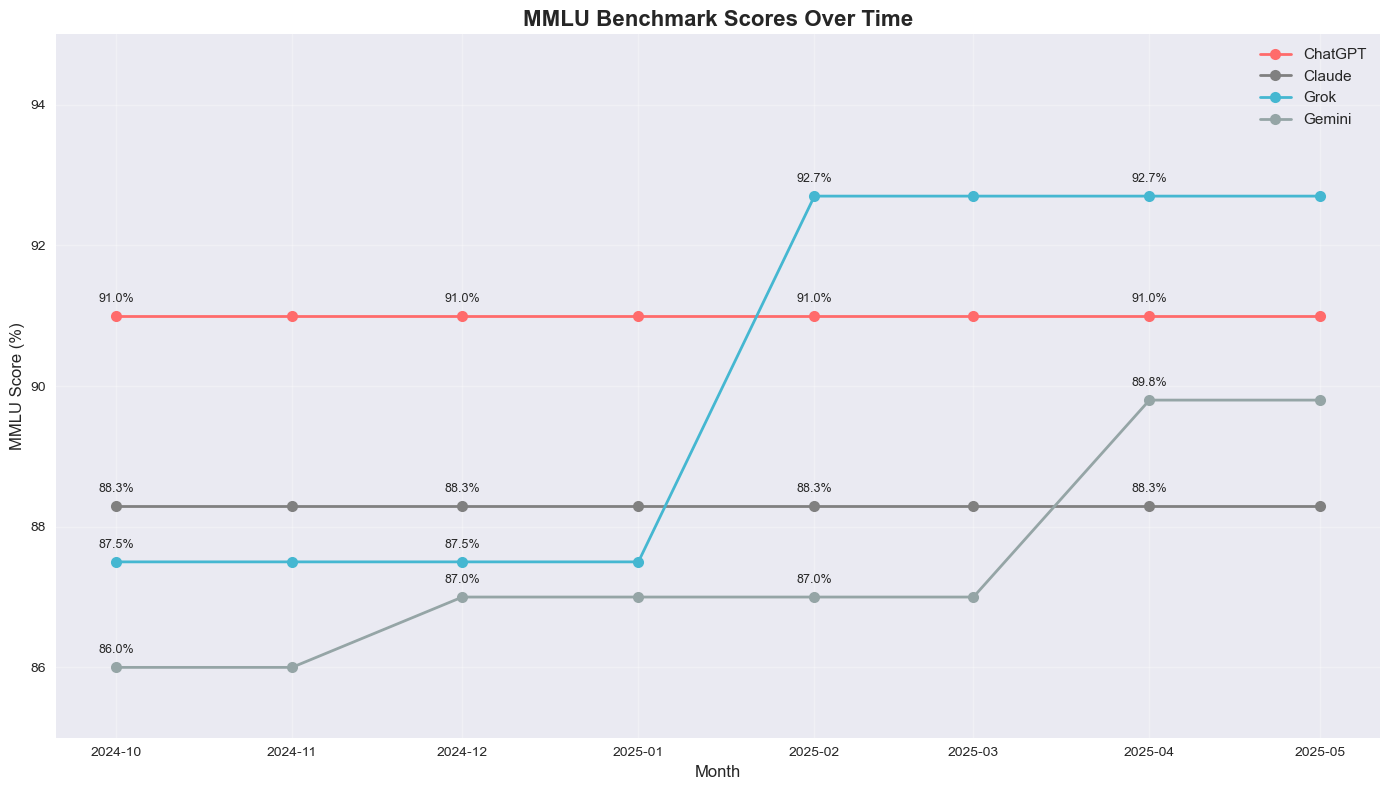

In [14]:
# Visualize Benchmark MMLU Scores
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot benchmark scores over time
colors = ['#ff6b6b', '#808080', '#45b7d1', '#95a5a6']
models = ['ChatGPT_Benchmark', 'Claude_Benchmark', 'Grok_Benchmark', 'Gemini_Benchmark']
model_labels = ['ChatGPT', 'Claude', 'Grok', 'Gemini']

for i, (model, label) in enumerate(zip(models, model_labels)):
    ax.plot(benchmark_df_clean['Month'], benchmark_df_clean[model],
            marker='o', linewidth=2, markersize=8, color=colors[i], label=label)

ax.set_title('MMLU Benchmark Scores Over Time', fontsize=16, fontweight='bold')
ax.set_ylabel('MMLU Score (%)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(85, 95)

# Add value labels on points
for i, (model, label) in enumerate(zip(models, model_labels)):
    for j, (month, score) in enumerate(zip(benchmark_df_clean['Month'], benchmark_df_clean[model])):
        if j % 2 == 0:  # Show every other point to avoid crowding
            ax.annotate(f'{score:.1f}%', (month, score),
                       textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# Calculate monthly sentiment ratios from our sentiment analysis data
monthly_sentiment_ratios = {}

for model in ['chatgpt', 'claude', 'gemini']:  # Only models available in both datasets
    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Group by month and calculate sentiment ratios
        monthly_data = model_mentioned.groupby('Month')[f'{model}_pred'].apply(
            lambda x: pd.Series({
                'Positive_Ratio': (x == 1).sum() / len(x) * 100,
                'Negative_Ratio': (x == -1).sum() / len(x) * 100,
                'Neutral_Ratio': (x == 0).sum() / len(x) * 100,
                'Net_Sentiment': ((x == 1).sum() - (x == -1).sum()) / len(x) * 100
            })
        ).unstack()

        monthly_sentiment_ratios[model] = monthly_data.reset_index()
        monthly_sentiment_ratios[model]['Month_Date'] = monthly_sentiment_ratios[model]['Month'].dt.to_timestamp()

print("Monthly sentiment ratios calculated for correlation analysis")

Monthly sentiment ratios calculated for correlation analysis


In [16]:
# Merge datasets for correlation analysis
correlation_data = {}

for model in ['chatgpt', 'claude', 'gemini']:
    # Create combined dataset
    model_data = pd.DataFrame()

    # Add sentiment data
    if model in monthly_sentiment_ratios:
        sentiment_data = monthly_sentiment_ratios[model].copy()
        model_data = sentiment_data

    # Add benchmark data
    benchmark_col = f'{model.title()}_Benchmark'
    if benchmark_col in benchmark_df_clean.columns:
        benchmark_subset = benchmark_df_clean[['Month', benchmark_col]].copy()
        if not model_data.empty:
            model_data = model_data.merge(benchmark_subset, left_on='Month_Date', right_on='Month', how='inner')
        else:
            model_data = benchmark_subset

    # Add market share data
    market_col = f'{model.title()}_MarketShare'
    if market_col in market_share_df_clean.columns:
        market_subset = market_share_df_clean[['Month', market_col]].copy()
        if not model_data.empty:
            model_data = model_data.merge(market_subset, left_on='Month_Date', right_on='Month', how='inner', suffixes=('', '_market'))
        else:
            model_data = market_subset

    if not model_data.empty:
        correlation_data[model] = model_data
        print(f"\n{model.upper()} combined data shape: {model_data.shape}")
        print(f"Available columns: {list(model_data.columns)}")

print(f"\nModels with complete data: {list(correlation_data.keys())}")


CHATGPT combined data shape: (8, 6)
Available columns: ['Month', 'Positive_Ratio', 'Negative_Ratio', 'Neutral_Ratio', 'Net_Sentiment', 'Month_Date']

CLAUDE combined data shape: (7, 10)
Available columns: ['Month_x', 'Positive_Ratio', 'Negative_Ratio', 'Neutral_Ratio', 'Net_Sentiment', 'Month_Date', 'Month_y', 'Claude_Benchmark', 'Month', 'Claude_MarketShare']

GEMINI combined data shape: (7, 10)
Available columns: ['Month_x', 'Positive_Ratio', 'Negative_Ratio', 'Neutral_Ratio', 'Net_Sentiment', 'Month_Date', 'Month_y', 'Gemini_Benchmark', 'Month', 'Gemini_MarketShare']

Models with complete data: ['chatgpt', 'claude', 'gemini']


In [17]:
# Calculate change rates for correlation analysis
change_data = {}

for model in correlation_data.keys():
    data = correlation_data[model].copy()
    change_df = pd.DataFrame()

    # Calculate change rates (month-over-month percentage change)
    numeric_cols = data.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col in data.columns and len(data) > 1:
            change_col_name = f'{col}_Change_Rate'
            change_df[change_col_name] = data[col].pct_change() * 100

    # Add original values for reference
    for col in ['Net_Sentiment', 'Positive_Ratio', 'Negative_Ratio']:
        if col in data.columns:
            change_df[col] = data[col]

    # Add benchmark and market share original values
    benchmark_col = f'{model.title()}_Benchmark'
    market_col = f'{model.title()}_MarketShare'
    if benchmark_col in data.columns:
        change_df[benchmark_col] = data[benchmark_col]
    if market_col in data.columns:
        change_df[market_col] = data[market_col]

    change_df['Month'] = data['Month_Date'] if 'Month_Date' in data.columns else data['Month']
    change_data[model] = change_df.dropna()  # Remove NaN values from pct_change

    print(f"\n{model.upper()} change data shape: {change_data[model].shape}")
    if not change_data[model].empty:
        print(f"Available columns: {list(change_data[model].columns)}")

print(f"\nModels with change data: {list(change_data.keys())}")


CHATGPT change data shape: (7, 8)
Available columns: ['Positive_Ratio_Change_Rate', 'Negative_Ratio_Change_Rate', 'Neutral_Ratio_Change_Rate', 'Net_Sentiment_Change_Rate', 'Net_Sentiment', 'Positive_Ratio', 'Negative_Ratio', 'Month']

CLAUDE change data shape: (6, 12)
Available columns: ['Positive_Ratio_Change_Rate', 'Negative_Ratio_Change_Rate', 'Neutral_Ratio_Change_Rate', 'Net_Sentiment_Change_Rate', 'Claude_Benchmark_Change_Rate', 'Claude_MarketShare_Change_Rate', 'Net_Sentiment', 'Positive_Ratio', 'Negative_Ratio', 'Claude_Benchmark', 'Claude_MarketShare', 'Month']

GEMINI change data shape: (6, 12)
Available columns: ['Positive_Ratio_Change_Rate', 'Negative_Ratio_Change_Rate', 'Neutral_Ratio_Change_Rate', 'Net_Sentiment_Change_Rate', 'Gemini_Benchmark_Change_Rate', 'Gemini_MarketShare_Change_Rate', 'Net_Sentiment', 'Positive_Ratio', 'Negative_Ratio', 'Gemini_Benchmark', 'Gemini_MarketShare', 'Month']

Models with change data: ['chatgpt', 'claude', 'gemini']


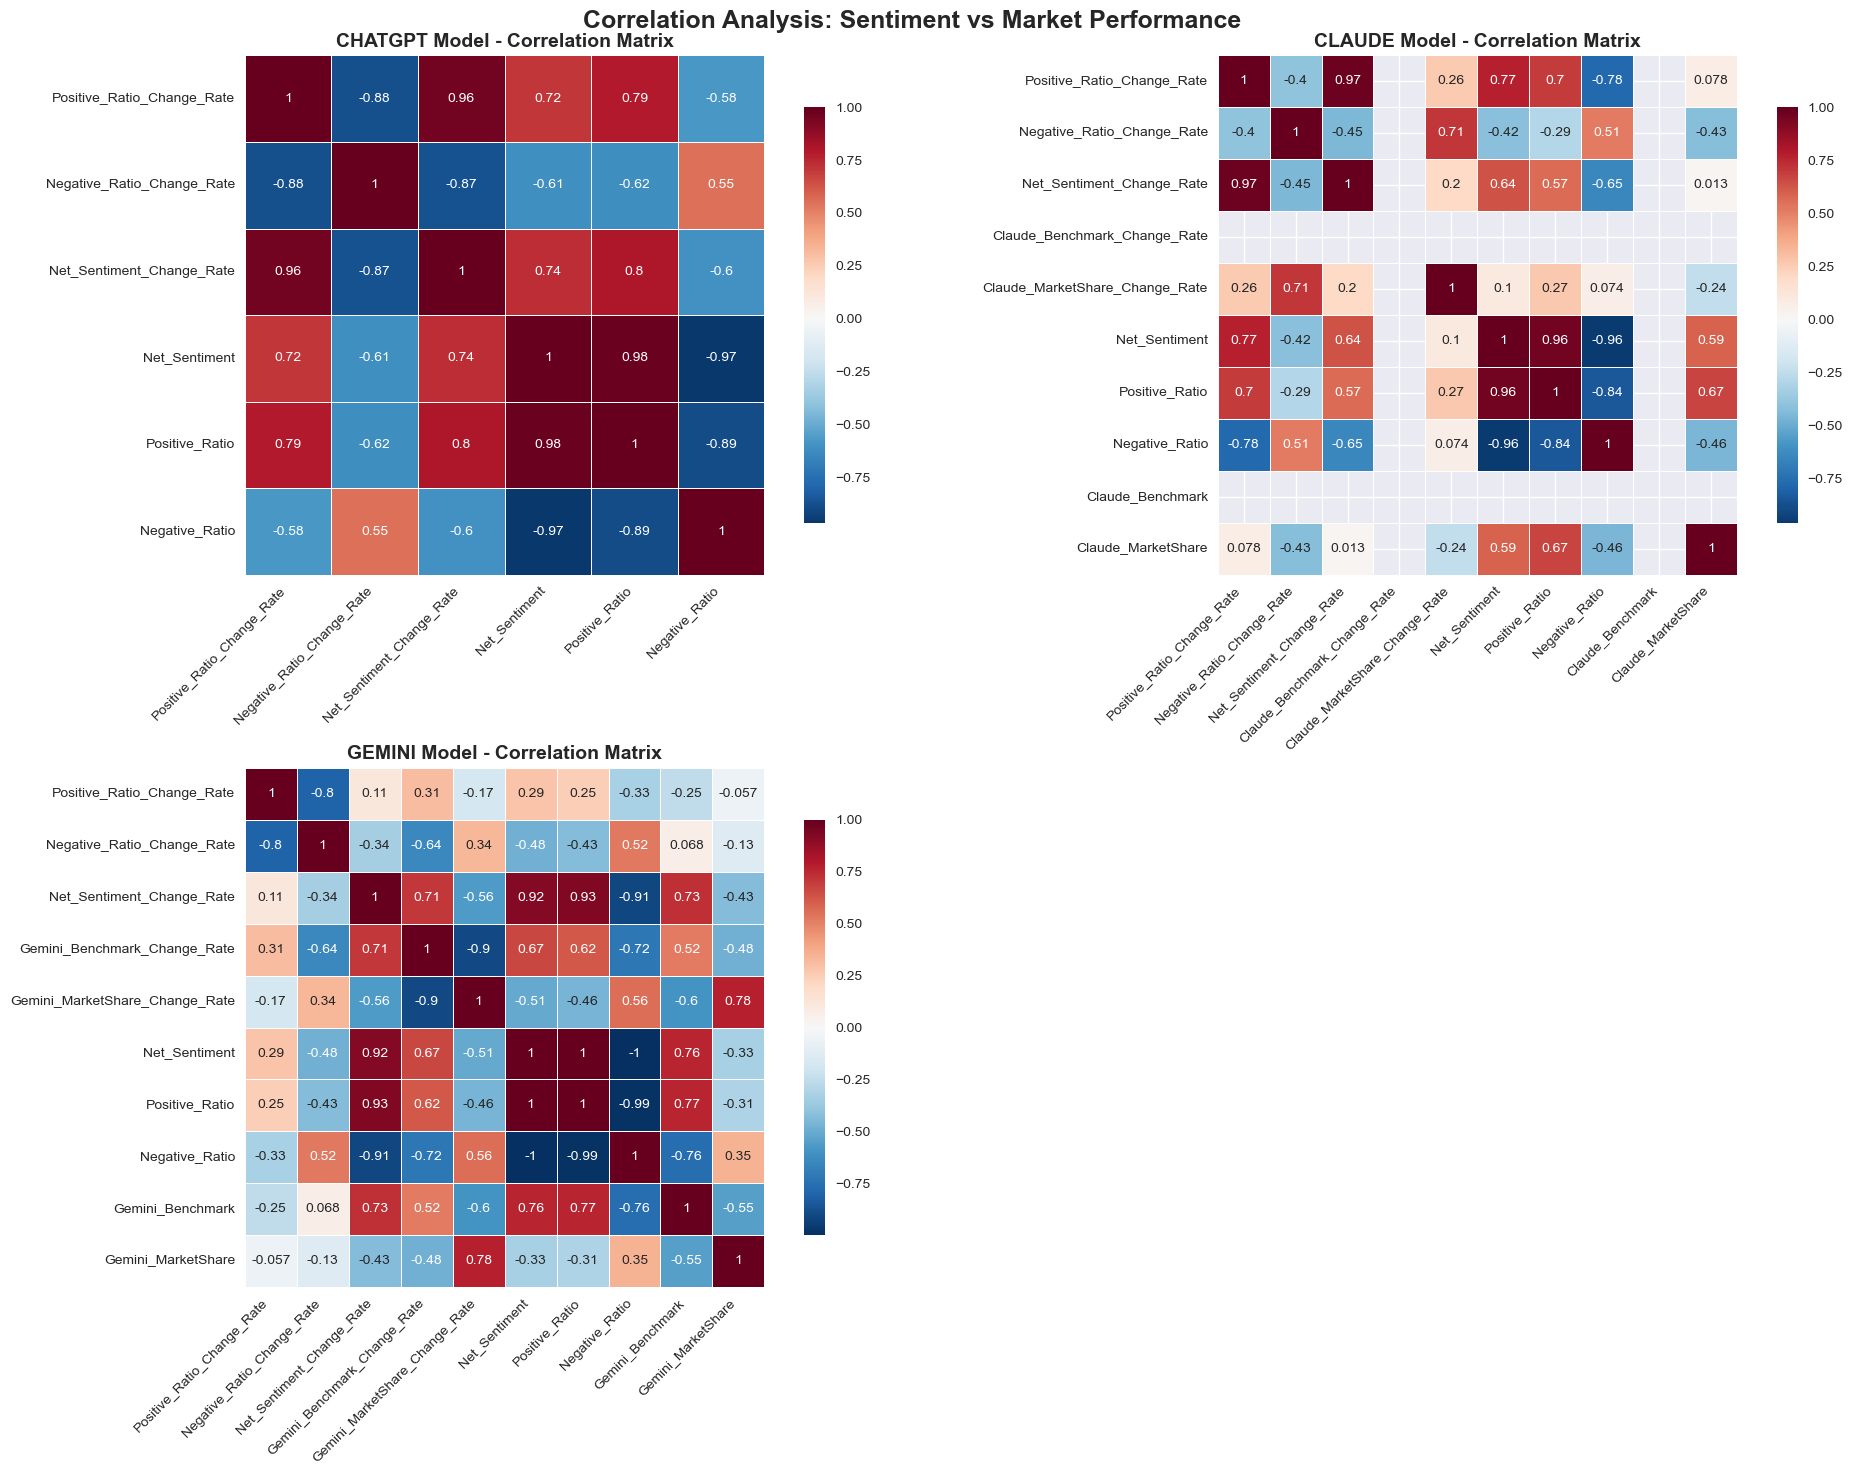

In [18]:
# Correlation Analysis Visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Correlation Analysis: Sentiment vs Market Performance', fontsize=18, fontweight='bold')

plot_idx = 0
for model in change_data.keys():
    if plot_idx >= 4:
        break

    data = change_data[model]
    row, col = plot_idx // 2, plot_idx % 2
    ax = axes[row, col]

    # Create correlation matrix for key metrics
    corr_cols = []
    for col in data.columns:
        if any(keyword in col.lower() for keyword in ['sentiment', 'positive', 'negative', 'benchmark', 'market']):
            if col not in ['Month'] and data[col].notna().sum() > 1:
                corr_cols.append(col)

    if len(corr_cols) > 1:
        corr_matrix = data[corr_cols].corr()

        # Create heatmap
        sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                   ax=ax, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
        ax.set_title(f'{model.upper()} Model - Correlation Matrix', fontsize=14, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.text(0.5, 0.5, f'{model.upper()}\nInsufficient data for correlation',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{model.upper()} Model - Insufficient Data', fontsize=14, fontweight='bold')

    plot_idx += 1

# Remove empty subplots
for i in range(plot_idx, 4):
    row, col = i // 2, i % 2
    axes[row, col].remove()

plt.tight_layout()
plt.show()

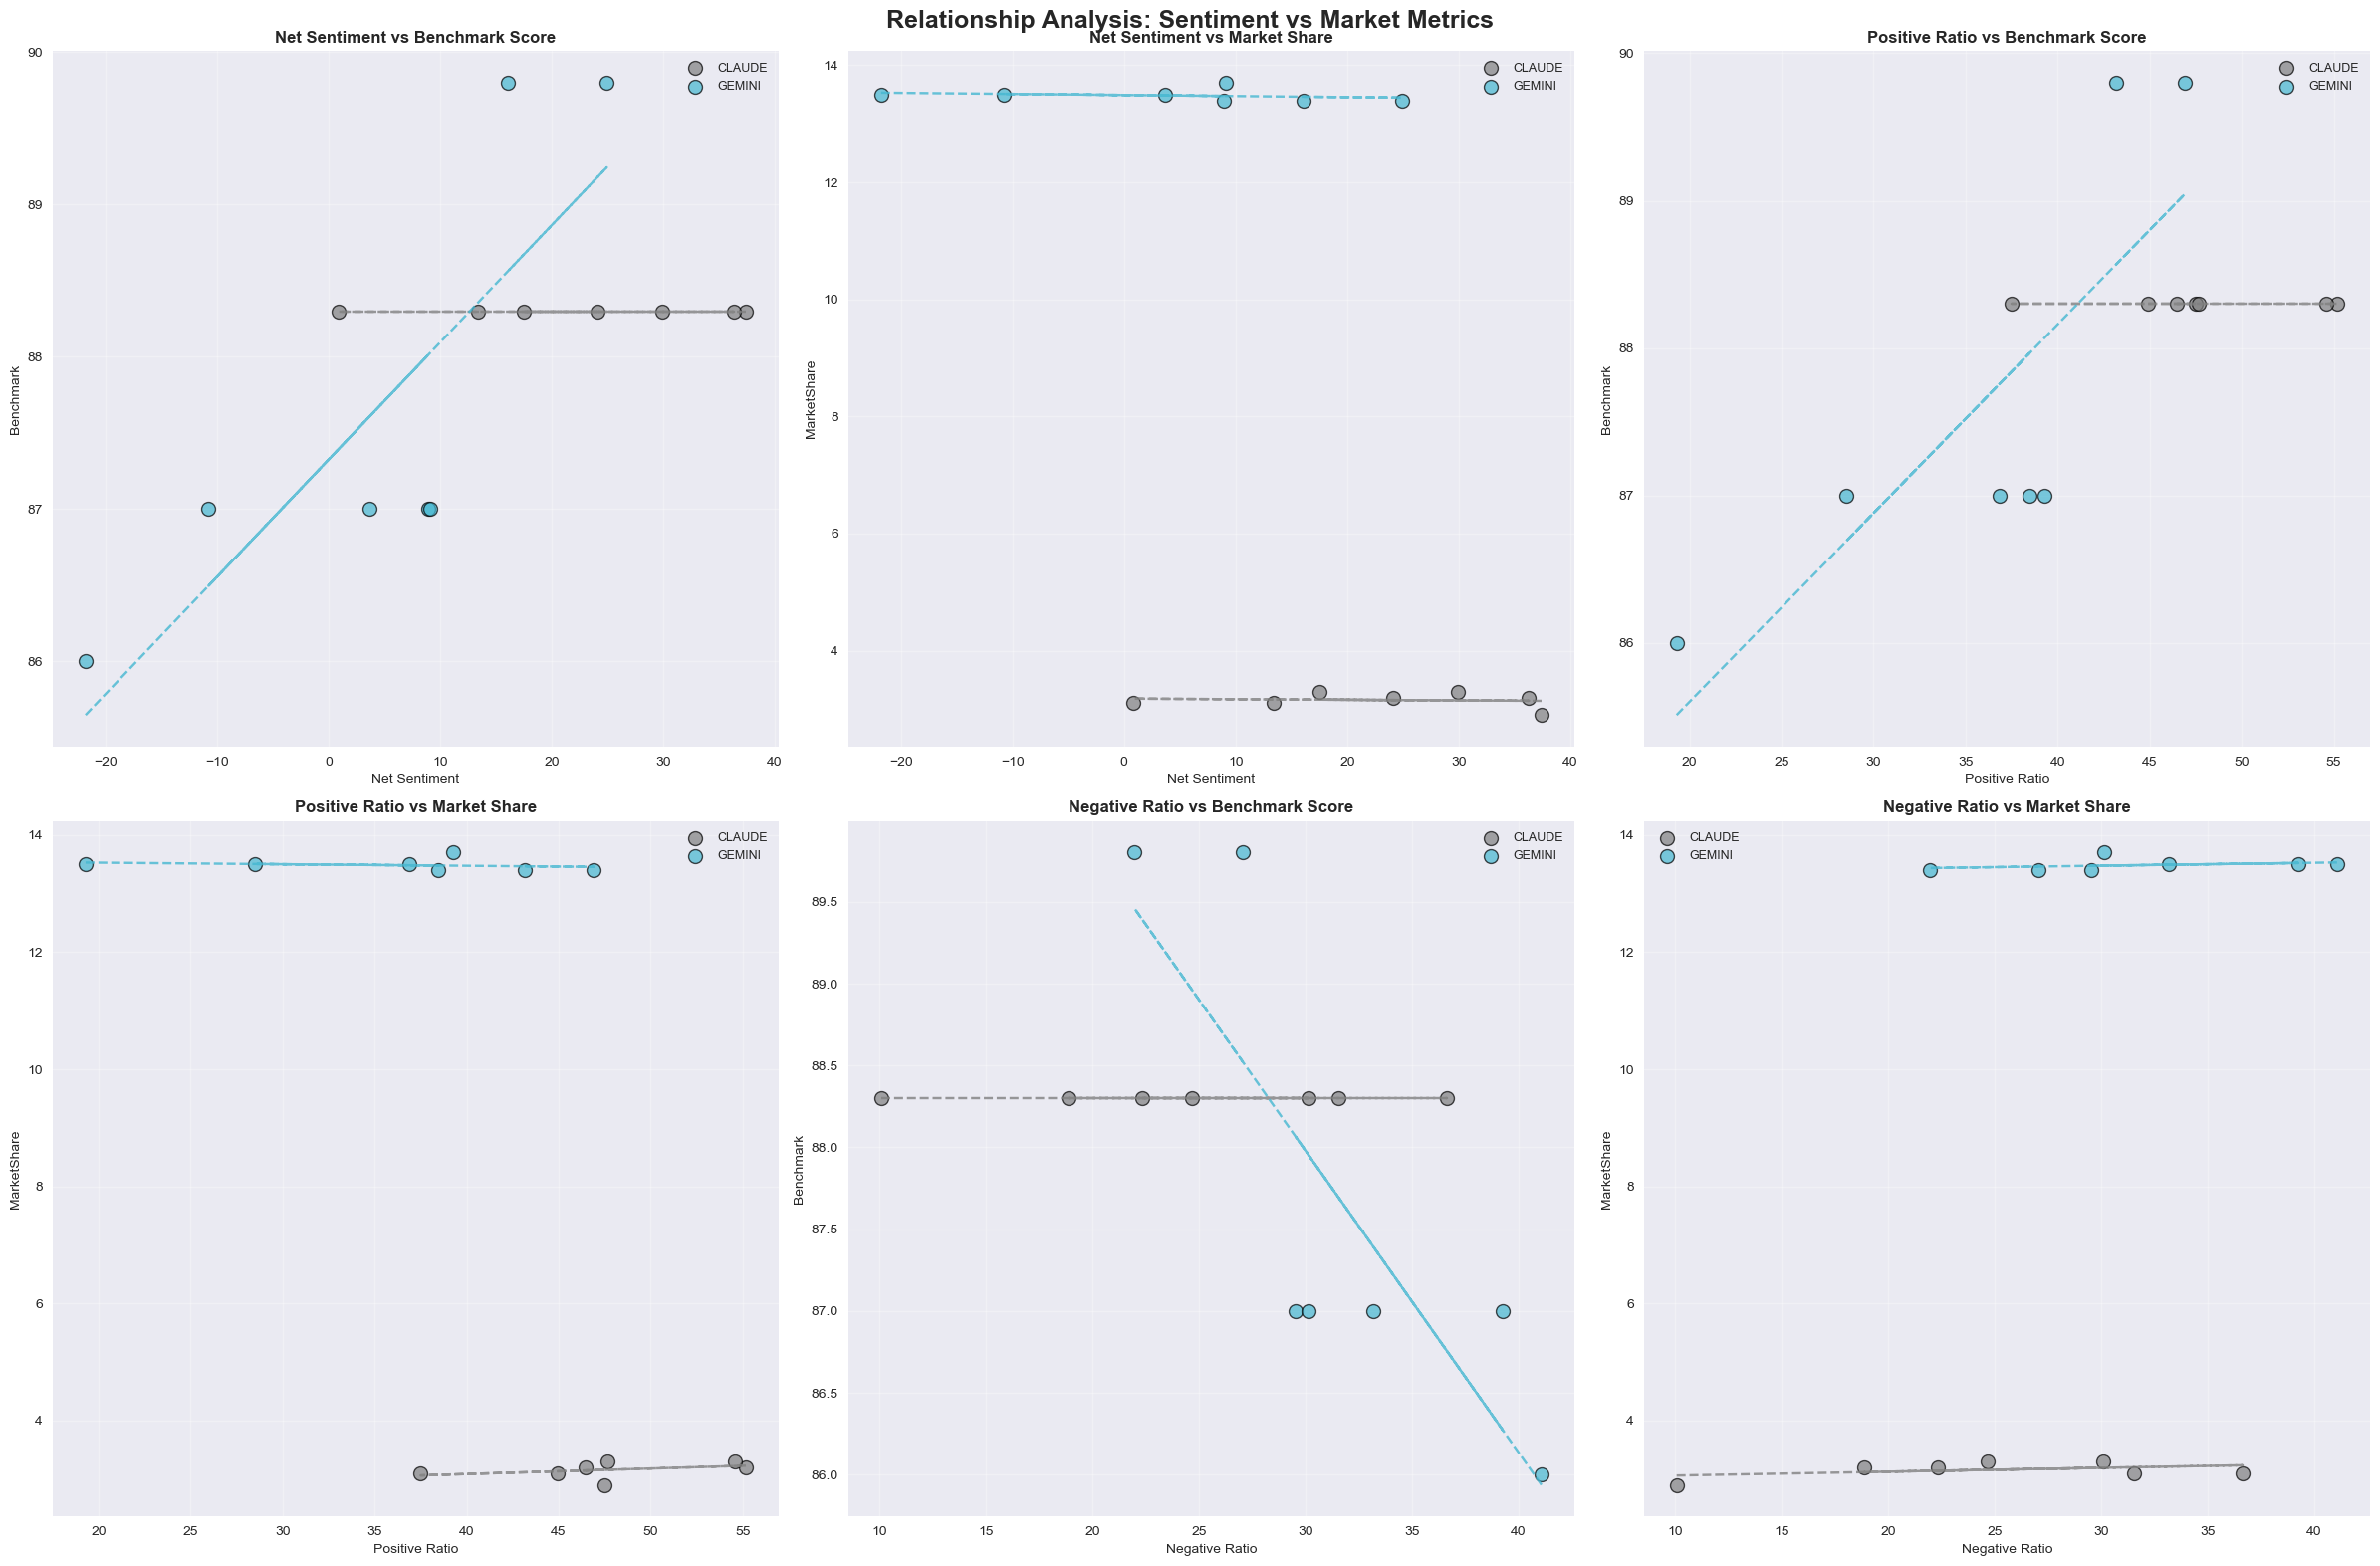

In [19]:
# Scatter plots for key relationships
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Relationship Analysis: Sentiment vs Market Metrics', fontsize=18, fontweight='bold')

plot_configs = [
    ('Net_Sentiment', 'Benchmark', 'Net Sentiment vs Benchmark Score'),
    ('Net_Sentiment', 'MarketShare', 'Net Sentiment vs Market Share'),
    ('Positive_Ratio', 'Benchmark', 'Positive Ratio vs Benchmark Score'),
    ('Positive_Ratio', 'MarketShare', 'Positive Ratio vs Market Share'),
    ('Negative_Ratio', 'Benchmark', 'Negative Ratio vs Benchmark Score'),
    ('Negative_Ratio', 'MarketShare', 'Negative Ratio vs Market Share')
]

colors = ['#ff6b6b', '#808080', '#45b7d1']
model_colors = dict(zip(['chatgpt', 'claude', 'gemini'], colors))

for plot_idx, (x_metric, y_metric, title) in enumerate(plot_configs):
    row, col = plot_idx // 3, plot_idx % 3
    ax = axes[row, col]

    for model in correlation_data.keys():
        data = correlation_data[model]

        # Find appropriate columns
        x_col = None
        y_col = None

        for col in data.columns:
            if x_metric.lower() in col.lower():
                x_col = col
            if y_metric.lower() in col.lower():
                y_col = col

        if x_col and y_col and x_col in data.columns and y_col in data.columns:
            # Remove NaN values
            clean_data = data[[x_col, y_col]].dropna()
            if len(clean_data) > 0:
                ax.scatter(clean_data[x_col], clean_data[y_col],
                          color=model_colors[model], alpha=0.7, s=100,
                          label=f'{model.upper()}', edgecolors='black', linewidth=1)

                # Add trend line
                if len(clean_data) > 1:
                    z = np.polyfit(clean_data[x_col], clean_data[y_col], 1)
                    p = np.poly1d(z)
                    ax.plot(clean_data[x_col], p(clean_data[x_col]),
                           color=model_colors[model], linestyle='--', alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(x_metric.replace('_', ' '), fontsize=10)
    ax.set_ylabel(y_metric.replace('_', ' '), fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
# Summary statistics and insights
print("=== Market Performance and Sentiment Analysis Summary ===")

print("\n1. MMLU Benchmark Performance:")
for model in ['ChatGPT_Benchmark', 'Claude_Benchmark', 'Grok_Benchmark', 'Gemini_Benchmark']:
    if model in benchmark_df_clean.columns:
        scores = benchmark_df_clean[model]
        model_name = model.replace('_Benchmark', '')
        print(f"  {model_name}: {scores.mean():.1f}% (±{scores.std():.1f}%), Range: {scores.min():.1f}%-{scores.max():.1f}%")

print("\n2. Market Share Performance:")
for model in ['ChatGPT_MarketShare', 'Claude_MarketShare', 'Gemini_MarketShare']:
    if model in market_share_df_clean.columns:
        shares = market_share_df_clean[model]
        model_name = model.replace('_MarketShare', '')
        print(f"  {model_name}: {shares.mean():.1f}% (±{shares.std():.1f}%), Range: {shares.min():.1f}%-{shares.max():.1f}%")

print("\n3. Sentiment Analysis Summary (for models mentioned in posts):")
for model in monthly_sentiment_ratios.keys():
    data = monthly_sentiment_ratios[model]
    if 'Net_Sentiment' in data.columns:
        net_sentiment = data['Net_Sentiment']
        print(f"  {model.upper()}: Net Sentiment {net_sentiment.mean():.1f}% (±{net_sentiment.std():.1f}%)")

print("\n4. Key Correlations Found:")
for model in change_data.keys():
    data = change_data[model]
    print(f"\n  {model.upper()} Model:")

    # Check specific correlations
    corr_pairs = [
        ('Net_Sentiment', 'Benchmark'),
        ('Net_Sentiment', 'MarketShare'),
        ('Positive_Ratio', 'Benchmark'),
        ('Negative_Ratio', 'MarketShare')
    ]

    for metric1, metric2 in corr_pairs:
        col1 = None
        col2 = None

        for col in data.columns:
            if metric1.lower() in col.lower():
                col1 = col
            if metric2.lower() in col.lower():
                col2 = col

        if col1 and col2 and col1 in data.columns and col2 in data.columns:
            clean_data = data[[col1, col2]].dropna()
            if len(clean_data) > 1:
                correlation = clean_data[col1].corr(clean_data[col2])
                print(f"    {metric1} vs {metric2}: r = {correlation:.3f}")

print(f"\n5. Analysis Period: {benchmark_df_clean['Month'].min().strftime('%Y-%m')} to {benchmark_df_clean['Month'].max().strftime('%Y-%m')}")

=== Market Performance and Sentiment Analysis Summary ===

1. MMLU Benchmark Performance:
  ChatGPT: 91.0% (±0.0%), Range: 91.0%-91.0%
  Claude: 88.3% (±0.0%), Range: 88.3%-88.3%
  Grok: 90.1% (±2.8%), Range: 87.5%-92.7%
  Gemini: 87.5% (±1.5%), Range: 86.0%-89.8%

2. Market Share Performance:
  ChatGPT: 74.1% (±0.4%), Range: 73.6%-74.9%
  Claude: 3.1% (±0.2%), Range: 2.8%-3.3%
  Gemini: 13.5% (±0.1%), Range: 13.4%-13.7%

3. Sentiment Analysis Summary (for models mentioned in posts):
  CHATGPT: Net Sentiment 22.8% (±9.6%)
  CLAUDE: Net Sentiment 23.1% (±12.2%)
  GEMINI: Net Sentiment 5.5% (±15.1%)

4. Key Correlations Found:

  CHATGPT Model:

  CLAUDE Model:
    Net_Sentiment vs Benchmark: r = nan
    Net_Sentiment vs MarketShare: r = 0.588
    Positive_Ratio vs Benchmark: r = nan
    Negative_Ratio vs MarketShare: r = -0.456

  GEMINI Model:
    Net_Sentiment vs Benchmark: r = 0.764
    Net_Sentiment vs MarketShare: r = -0.328
    Positive_Ratio vs Benchmark: r = 0.765
    Negative_R

/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
